In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
sns.set(font_scale=1.1)


In [3]:
df = pd.read_csv("transactions.csv")
df.head(10)

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0
5,6,1,141,47,147.93,224.82,FR,FR,web,travel,0,1,1,1,2024-01-26T22:05:08Z,289.06,0
6,7,1,141,47,147.93,125.98,FR,FR,app,electronics,0,1,1,1,2024-01-30T00:51:41Z,443.75,0
7,8,1,141,47,147.93,66.95,FR,RO,web,travel,0,1,1,1,2024-02-11T15:33:30Z,1390.59,0
8,9,1,141,47,147.93,261.58,FR,FR,app,grocery,0,0,0,0,2024-02-22T01:29:55Z,110.51,0
9,10,1,141,47,147.93,97.34,FR,FR,web,electronics,0,0,1,1,2024-03-09T11:13:19Z,232.34,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,299695.0,149848.000000,86514.638800,1.00,74924.50,149848.00,224771.50,299695.00
user_id,299695.0,3002.559432,1732.309663,1.00,1501.00,3007.00,4504.00,6000.00
account_age_days,299695.0,973.397871,525.241409,1.00,516.00,975.00,1425.00,1890.00
total_transactions_user,299695.0,50.673321,5.976391,40.00,46.00,51.00,56.00,60.00
avg_amount_user,299695.0,148.142973,200.364624,3.52,46.19,90.13,173.45,4565.29
amount,299695.0,177.165279,306.926507,1.00,42.10,89.99,191.11,16994.74
promo_used,299695.0,0.153640,0.360603,0.00,0.00,0.00,0.00,1.00
avs_match,299695.0,0.837999,0.368453,0.00,1.00,1.00,1.00,1.00
cvv_result,299695.0,0.872110,0.333968,0.00,1.00,1.00,1.00,1.00
three_ds_flag,299695.0,0.784588,0.411109,0.00,1.00,1.00,1.00,1.00


The Target: How much fraud is there?
The bar for 0 (legitimate) will be huge, and 1 (fraud) will be tiny.

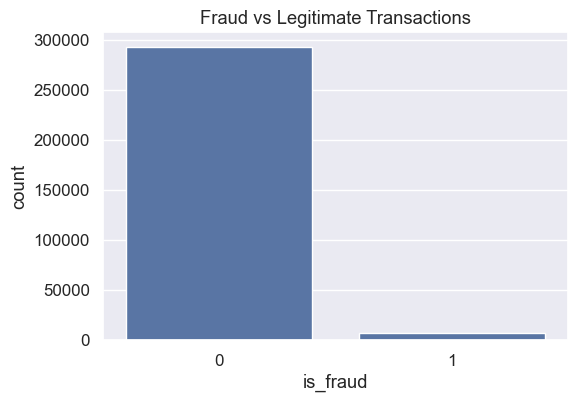

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_fraud",data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

The Money: What is the distribution of transaction amounts?

> Since transaction amounts often have huge outliers (mostly small purchases, a few huge ones), we often use a "log scale" to see them better.

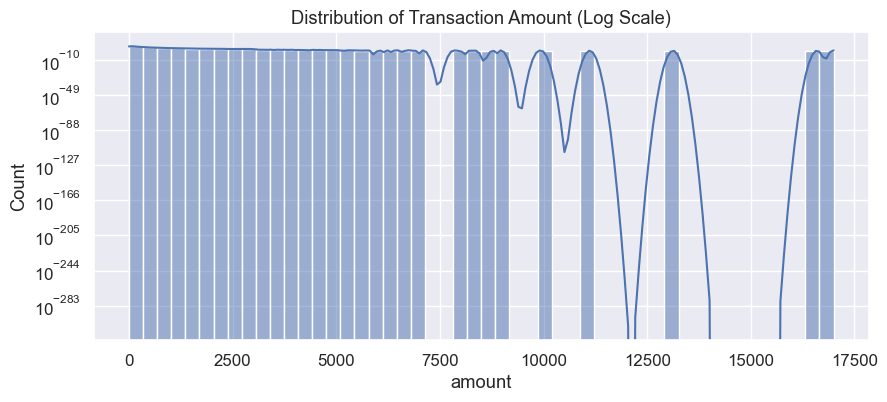

In [10]:
plt.figure(figsize=(10,4))
sns.histplot(df['amount'], bins=50, kde=True)
plt.yscale('log')
plt.title('Distribution of Transaction Amount (Log Scale)')
plt.show()

## The Categories: Where is fraud happening?

> Does fraud happen more on the web or mobile? In electronics or grocery?

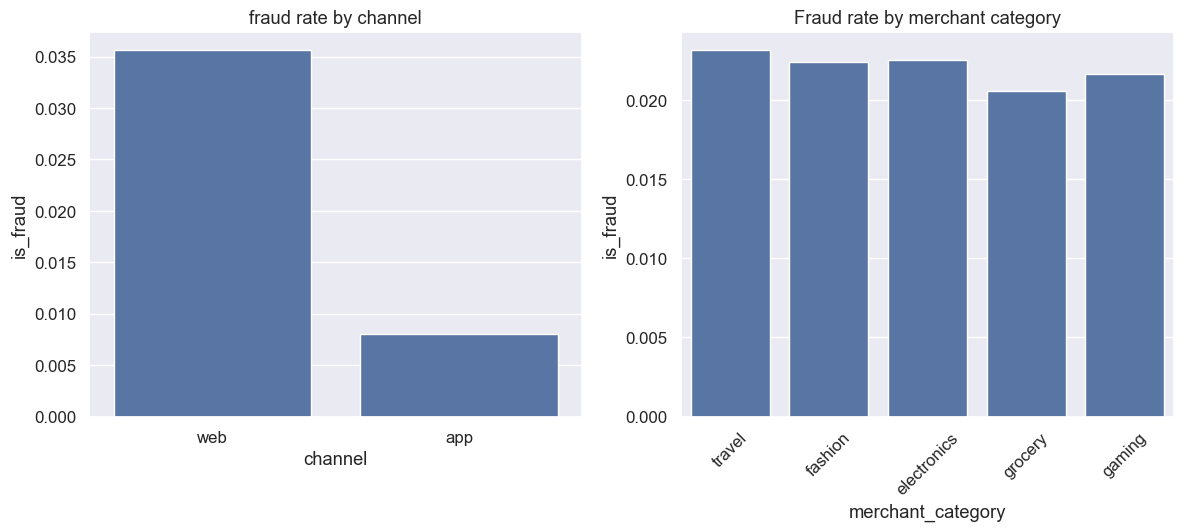

In [12]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# plot 1: fraud by channel 
sns.barplot(x='channel', y='is_fraud', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('fraud rate by channel')

# plot 2: Fraud by marchent category
sns.barplot(x='merchant_category', y='is_fraud', data=df, ax=axes[1],errorbar=None)
axes[1].set_title('Fraud rate by merchant category')
axes[1].tick_params(axis='x', rotation=45)
plt.show()


> Observation: You will likely see that electronics or travel have higher bars, meaning they are riskier categories. This is a very valuable insight for a business!

## Step 3: "How are things related?" (Correlation & Time)

> This checks if variables move together. For example, does a higher amount usually mean a higher chance of is_fraud?

### Correlation Heatmap

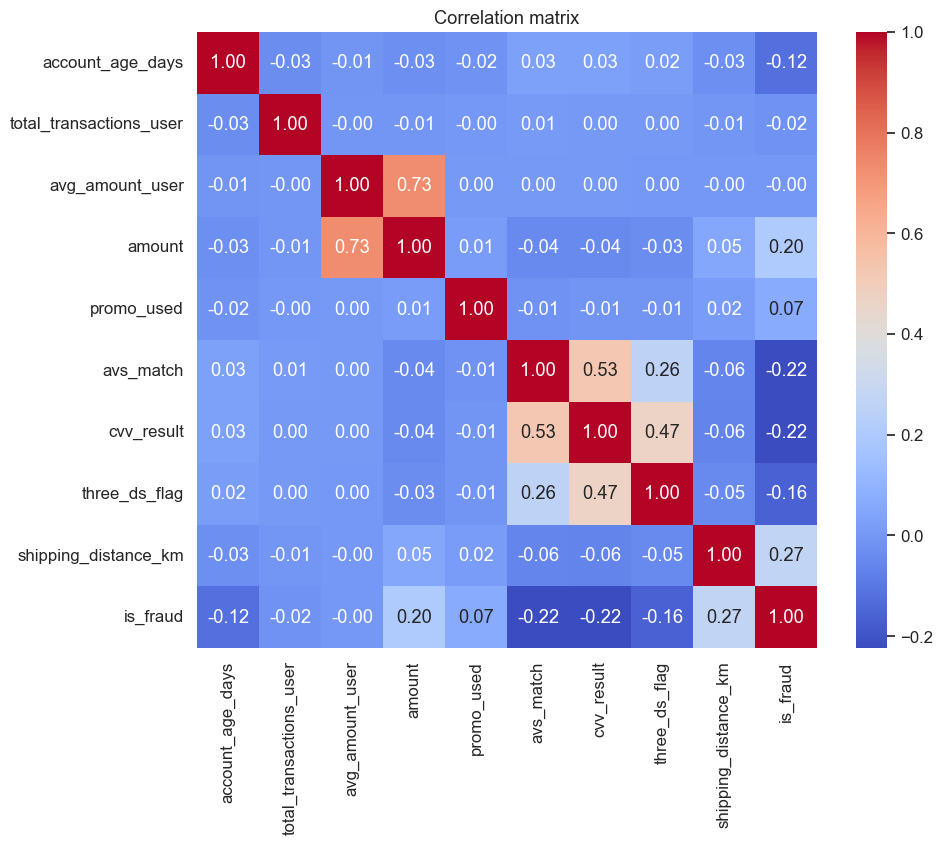

In [21]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Remove ID columns as they are just random numbers
numerical_cols = [c for c in numerical_cols if c not in ['transaction_id', 'user_id']]

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation matrix")
plt.show()

### Time Analysis: When does fraud happen?

> dataset has a timestamp. Let's see if fraud happens at night!

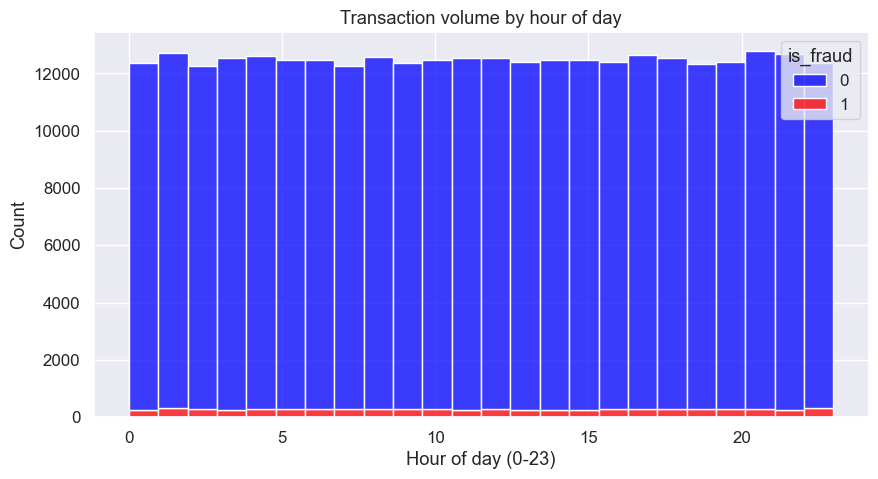

In [23]:
# Convert the string time to a real datetime object
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

# Extract the hour (0-23)
df['hour'] = df['transaction_time'].dt.hour

plt.figure(figsize=(10,5))
# Plot a histogram of hours, colored by fraud status


sns.histplot(data=df, x='hour',bins=24, hue='is_fraud', multiple='stack', palette={0:'blue',1:'red'})
plt.title('Transaction volume by hour of day')
plt.xlabel("Hour of day (0-23)")
plt.show()

> Observation: Look for red spikes. If you see a lot of red (fraud) at 3 AM, that's a strong pattern!